In [2]:
#drive mount and setup
from google.colab import drive
import os, tensorflow as tf

drive.mount('/content/drive')

print("TF Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

#  Paths
BASE_PATH      = "/content/drive/MyDrive/bio-heritage-ai/plant_disease"
PROCESSED_PATH = f"{BASE_PATH}/datasets/processed"
MODEL_SAVE     = f"{BASE_PATH}/models/saved/efficientnetb4_v3.keras"
CHECKPOINT     = f"{BASE_PATH}/models/checkpoints/best_model_v3.keras"

os.makedirs(f"{BASE_PATH}/models/saved",       exist_ok=True)
os.makedirs(f"{BASE_PATH}/models/checkpoints", exist_ok=True)
os.makedirs(f"{BASE_PATH}/results/plots",      exist_ok=True)
os.makedirs(f"{BASE_PATH}/results/metrics",    exist_ok=True)

print(" Setup complete!")
print(f"   Model will save to: {MODEL_SAVE}")

Mounted at /content/drive
TF Version: 2.20.0
GPU: []
 Setup complete!
   Model will save to: /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/saved/efficientnetb4_v3.keras


In [ ]:
import shutil, random, os
from PIL import Image
import hashlib
from tqdm.notebook import tqdm

SPLIT_RATIO     = (0.8, 0.1, 0.1)
MAX_HEALTHY     = 1200  # Healthy class limit
CLASSES         = ['Healthy', 'Rust', 'Rot', 'Anthracnose', 'Bacterial_Leaf_Spot']

CLASS_MAPPING = {
    f"{BASE_PATH}/datasets/raw/aloe_vera/crop_images/healthy_leaf" : "Healthy",
    f"{BASE_PATH}/datasets/raw/aloe_vera/crop_images/rust"         : "Rust",
    f"{BASE_PATH}/datasets/raw/aloe_vera/crop_images/rot"          : "Rot",
    f"{BASE_PATH}/datasets/raw/betel_leaf/Hijau_Sehat/images"      : "Healthy",
    f"{BASE_PATH}/datasets/raw/betel_leaf/Merah_Sehat/images"      : "Healthy",
    f"{BASE_PATH}/datasets/raw/betel_leaf/Hijau_Antraknos/images"  : "Anthracnose",
    f"{BASE_PATH}/datasets/raw/betel_leaf/Hijau_Karat/images"      : "Bacterial_Leaf_Spot",
}

# ── Step 1: Clear old processed data ──────────────
print("  Clearing old processed data...")
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        path = f"{PROCESSED_PATH}/{split}/{cls}"
        if os.path.exists(path):
            shutil.rmtree(path)
        os.makedirs(path)
print(" Old data cleared!\n")

# ── Step 2: Image validation functions ────────────
def is_valid_image(filepath):
    try:
        with Image.open(filepath) as img:
            img.verify()
        with Image.open(filepath) as img:
            img.load()
            if img.size[0] < 50 or img.size[1] < 50:
                return False, "too_small"
        return True, "ok"
    except Exception as e:
        return False, str(e)

def get_image_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# ── Step 3: Collect all valid images per class ────
print(" Scanning and validating images...")
print("-" * 60)

class_images = {cls: [] for cls in CLASSES}
seen_hashes  = set()

stats = {
    'total_found' : 0,
    'corrupted'   : 0,
    'too_small'   : 0,
    'duplicates'  : 0,
    'valid'       : 0,
}

for src_path, class_name in CLASS_MAPPING.items():
    if not os.path.exists(src_path):
        print(f"   Not found: {src_path}")
        continue

    all_files   = [f for f in os.listdir(src_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    folder_name = os.path.basename(src_path)

    valid_count  = 0
    corrupt_count= 0
    small_count  = 0
    dup_count    = 0

    for fname in tqdm(all_files, desc=f"  {class_name} ← {folder_name}", leave=False):
        fpath = os.path.join(src_path, fname)
        stats['total_found'] += 1

        valid, reason = is_valid_image(fpath)
        if not valid:
            if reason == "too_small":
                small_count += 1
                stats['too_small'] += 1
            else:
                corrupt_count += 1
                stats['corrupted'] += 1
            continue

        img_hash = get_image_hash(fpath)
        if img_hash in seen_hashes:
            dup_count += 1
            stats['duplicates'] += 1
            continue
        seen_hashes.add(img_hash)

        unique_name = f"{folder_name}_{fname}"
        class_images[class_name].append((fpath, unique_name))
        valid_count += 1
        stats['valid'] += 1

    print(f"   {class_name:<25} ← {folder_name}")
    print(f"     Found: {len(all_files):>4} | Valid: {valid_count:>4} | "
          f"Corrupt: {corrupt_count:>2} | Small: {small_count:>2} | Dup: {dup_count:>2}")

print("\n" + "=" * 60)
print(f"   SCAN SUMMARY (before undersample)")
print(f"  Total found    : {stats['total_found']}")
print(f"  Corrupted      : {stats['corrupted']}")
print(f"  Too small      : {stats['too_small']}")
print(f"  Duplicates     : {stats['duplicates']}")
print(f"   Valid images : {stats['valid']}")
print("=" * 60)

# ── Step 4: Undersample Healthy ───────────────────
print(f"\n  Undersampling Healthy class...")
print(f"   Before : {len(class_images['Healthy'])} images")

random.seed(42)
class_images['Healthy'] = random.sample(
    class_images['Healthy'],
    min(MAX_HEALTHY, len(class_images['Healthy']))
)
print(f"   After  : {len(class_images['Healthy'])} images (limit: {MAX_HEALTHY})")

# ── Step 5: Split + Copy ──────────────────────────
print("\n Splitting and copying images...")

random.seed(42)
total_copied = 0

for cls in CLASSES:
    images = class_images[cls]
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * SPLIT_RATIO[0])
    n_val   = int(n * SPLIT_RATIO[1])

    splits = {
        'train': images[:n_train],
        'val'  : images[n_train : n_train + n_val],
        'test' : images[n_train + n_val:]
    }

    for split_name, split_imgs in splits.items():
        dest = f"{PROCESSED_PATH}/{split_name}/{cls}"
        for src_fpath, dest_fname in split_imgs:
            shutil.copy(src_fpath, os.path.join(dest, dest_fname))
        total_copied += len(split_imgs)

print(f" Total images copied: {total_copied}")

# ── Step 6: Final verification ────────────────────
print(f"\n{'Class':<25} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 57)
grand_total = 0
for cls in CLASSES:
    counts = []
    for split in ['train', 'val', 'test']:
        path  = f"{PROCESSED_PATH}/{split}/{cls}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        counts.append(count)
    row_total    = sum(counts)
    grand_total += row_total
    print(f"{cls:<25} {counts[0]:>8} {counts[1]:>8} {counts[2]:>8} {row_total:>8}")
print("-" * 57)
print(f"{'TOTAL':<25} {grand_total:>32}")

# ── Step 7: Balance check ─────────────────────────
print("\n Class Balance Check (Train set):")
train_counts = []
for cls in CLASSES:
    path  = f"{PROCESSED_PATH}/train/{cls}"
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    train_counts.append(count)

max_count = max(train_counts)
for cls, count in zip(CLASSES, train_counts):
    bar   = " " * int(count / max_count * 30)
    ratio = count / max_count
    print(f"  {cls:<25}: {count:>5}  {bar}  ({ratio:.2f}x)")

print("\n Enhanced preprocessing with undersampling complete!")

  Clearing old processed data...
 Old data cleared!

 Scanning and validating images...
------------------------------------------------------------


  Healthy ← healthy_leaf:   0%|          | 0/1033 [00:00<?, ?it/s]

   Healthy                   ← healthy_leaf
     Found: 1033 | Valid: 1030 | Corrupt:  0 | Small:  0 | Dup:  3


  Rust ← rust:   0%|          | 0/1340 [00:00<?, ?it/s]

   Rust                      ← rust
     Found: 1340 | Valid: 1104 | Corrupt:  0 | Small:  0 | Dup: 236


...

   Healthy                   ← images
     Found: 1000 | Valid: 1000 | Corrupt:  0 | Small:  0 | Dup:  0


  Anthracnose ← images:   0%|          | 0/1000 [00:00<?, ?it/s]

   Anthracnose               ← images
     Found: 1000 | Valid: 1000 | Corrupt:  0 | Small:  0 | Dup:  0


  Bacterial_Leaf_Spot ← images:   0%|          | 0/1000 [00:00<?, ?it/s]

   Bacterial_Leaf_Spot       ← images
     Found: 1000 | Valid: 1000 | Corrupt:  0 | Small:  0 | Dup:  0

   SCAN SUMMARY (before undersample)
  Total found    : 7495
  Corrupted      : 0
  Too small      : 0
  Duplicates     : 436
   Valid images : 7059

  Undersampling Healthy class...
   Before : 3030 images
   After  : 1200 images (limit: 1200)

 Splitting and copying images...
 Total images copied: 5229

Class                        Train      Val     Test    Total
---------------------------------------------------------
Healthy                        960      120      120     1200
Rust                           883      110      111     1104
Rot                            740       92       93      925
Anthracnose                    800      100      100     1000
Bacterial_Leaf_Spot            800      100      100     1000
---------------------------------------------------------
TOTAL                                                 5229

 Class Balance Check (Train set):
  Hea

In [ ]:
#data generater
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import json

IMG_SIZE   = 224
BATCH_SIZE = 16

#  EfficientNetB4 correct preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   #  rescale
    rotation_range         = 40,
    width_shift_range      = 0.2,
    height_shift_range     = 0.2,
    horizontal_flip        = True,
    vertical_flip          = True,
    zoom_range             = 0.25,
    shear_range            = 0.15,
    brightness_range       = [0.8, 1.2],
    fill_mode              = 'nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input    #   update
)

train_gen = train_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/train",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True
)
val_gen = val_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/val",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)
test_gen = val_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/test",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

# Save class indices
with open(f"{BASE_PATH}/models/saved/class_indices_v3.json", "w") as f:
    json.dump(train_gen.class_indices, f, indent=2)

print(" Generators ready!")
print("   Classes:", train_gen.class_indices)
print(f"   Train batches : {len(train_gen)}")
print(f"   Val batches   : {len(val_gen)}")
print(f"   Test batches  : {len(test_gen)}")

Found 4183 images belonging to 5 classes.
Found 522 images belonging to 5 classes.
Found 524 images belonging to 5 classes.
 Generators ready!
   Classes: {'Anthracnose': 0, 'Bacterial_Leaf_Spot': 1, 'Healthy': 2, 'Rot': 3, 'Rust': 4}
   Train batches : 262
   Val batches   : 33
   Test batches  : 33


In [ ]:
#class weight and model build
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                      Dropout, BatchNormalization)
from tensorflow.keras.models import Model

NUM_CLASSES = 5

# ── Class Weights (auto calculate from actual folder counts) ──
print(" Class Weights:")
total_train = sum(
    len(os.listdir(f"{PROCESSED_PATH}/train/{cls}"))
    for cls in CLASSES
)

class_weights = {}
for cls_name, idx in train_gen.class_indices.items():
    count = len(os.listdir(f"{PROCESSED_PATH}/train/{cls_name}"))
    weight = total_train / (NUM_CLASSES * count)
    class_weights[idx] = weight
    print(f"   {cls_name:<25}: count={count:>4} | weight={weight:.4f}")

print(f"\n   Total train images: {total_train}")

# ── Model Build ───────────────────────────────────
base_model = EfficientNetB4(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = BatchNormalization()(x)
x      = Dense(512, activation='relu')(x)
x      = Dropout(0.4)(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

print(f"\n Model built!")
print(f"   Total params    : {model.count_params():,}")
print(f"   Trainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")

 Class Weights:
   Anthracnose              : count= 800 | weight=1.0457
   Bacterial_Leaf_Spot      : count= 800 | weight=1.0457
   Healthy                  : count= 960 | weight=0.8715
   Rot                      : count= 740 | weight=1.1305
   Rust                     : count= 883 | weight=0.9475

   Total train images: 4183

 Model built!
   Total params    : 18,731,620
   Trainable params: 1,054,213


In [ ]:
#Phase 1 Training
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau)

callbacks = [
    ModelCheckpoint(
        CHECKPOINT,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor             = 'val_accuracy',
        patience            = 10,
        restore_best_weights= True,
        verbose             = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.2,
        patience = 5,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

print("=" * 50)
print("PHASE 1: Training top layers (base frozen)...")
print("=" * 50)
print(f"   Trainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
print(f"   Epochs          : 20")
print(f"   Learning rate   : 0.001\n")

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    callbacks       = callbacks,
    class_weight    = class_weights,
    verbose         = 1
)

p1_best = max(history1.history['val_accuracy'])
p1_last_train = history1.history['accuracy'][-1]
p1_last_val   = history1.history['val_accuracy'][-1]

print(f"\n Phase 1 Complete!")
print(f"   Best Val Accuracy  : {p1_best:.4f} ({p1_best*100:.2f}%)")
print(f"   Last Train Accuracy: {p1_last_train:.4f} ({p1_last_train*100:.2f}%)")
print(f"   Last Val Accuracy  : {p1_last_val:.4f} ({p1_last_val*100:.2f}%)")
print(f"   Gap                : {abs(p1_last_train - p1_last_val)*100:.2f}%")

PHASE 1: Training top layers (base frozen)...
   Trainable params: 1,054,213
   Epochs          : 20
   Learning rate   : 0.001

Epoch 1/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5686 - loss: 1.2881
Epoch 1: val_accuracy improved from None to 0.80843, saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best_model_v3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best_model_v3.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 930s 3s/step - accuracy: 0.6431 - loss: 1.0038 - val_accuracy: 0.8084 - val_loss: 0.4957 - learning_rate: 0.0010
Epoch 2/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7276 - loss: 0.6747
Epoch 2: val_accuracy improved from 0.80843 to 0.82567, saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best_model_v3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/

In [ ]:
#Phase 2
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau)
import tensorflow as tf


print("PHASE 2: Fine-tuning last 30 layers...")


# ── Unfreeze last 30 layers only ──────────────────
for layer in model.layers:
    layer.trainable = True
for layer in model.layers[:-30]:
    layer.trainable = False

# BatchNorm layers frozen  (important!)
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"   Trainable layers : {trainable_count}")
print(f"   Epochs           : 40")
print(f"   Learning rate    : 0.00005\n")

# ── Callbacks (stronger) ──────────────────────────
callbacks_p2 = [
    ModelCheckpoint(
        CHECKPOINT,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 12,           # ←  patience
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,                      # ← LR
        patience = 4,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

# ── Compile with L2 regularization ───────────────
optimizer = tf.keras.optimizers.Adam(
    learning_rate = 0.00005,
    weight_decay  = 1e-4       # ← L2 regularization (overfit prevent)
)

model.compile(
    optimizer = optimizer,
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 40,
    callbacks       = callbacks_p2,
    class_weight    = class_weights,
    verbose         = 1
)

p2_best       = max(history2.history['val_accuracy'])
p2_last_train = history2.history['accuracy'][-1]
p2_last_val   = history2.history['val_accuracy'][-1]
gap           = abs(p2_last_train - p2_last_val)

print(f"\n Phase 2 Complete!")
print(f"   Best Val Accuracy  : {p2_best:.4f} ({p2_best*100:.2f}%)")
print(f"   Last Train Accuracy: {p2_last_train:.4f} ({p2_last_train*100:.2f}%)")
print(f"   Last Val Accuracy  : {p2_last_val:.4f} ({p2_last_val*100:.2f}%)")
print(f"   Gap                : {gap*100:.2f}%")

if gap < 0.03:
    print("    Excellent — Not overfit!")
elif gap < 0.07:
    print("    Acceptable — Mild gap only")
else:
    print("     Gap still high — check Cell 7 graph")

# ── Save model ─────────────────────────────────────
model.save(MODEL_SAVE)
print(f"\n Model saved: {MODEL_SAVE}")

PHASE 2: Fine-tuning last 30 layers...
   Trainable layers : 24
   Epochs           : 40
   Learning rate    : 0.00005

Epoch 1/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8944 - loss: 0.2549
Epoch 1: val_accuracy improved from None to 0.94636, saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best_model_v3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best_model_v3.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 1020s 4s/step - accuracy: 0.9029 - loss: 0.2456 - val_accuracy: 0.9464 - val_loss: 0.1411 - learning_rate: 5.0000e-05
Epoch 2/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9139 - loss: 0.2376
Epoch 2: val_accuracy improved from 0.94636 to 0.95402, saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best_model_v3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best

In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

#  Variables restore
import os, tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BASE_PATH      = "/content/drive/MyDrive/bio-heritage-ai/plant_disease"
PROCESSED_PATH = f"{BASE_PATH}/datasets/processed"
MODEL_SAVE     = f"{BASE_PATH}/models/saved/efficientnetb4_v3.keras"
CHECKPOINT     = f"{BASE_PATH}/models/checkpoints/best_model_v3.keras"
IMG_SIZE       = 224
BATCH_SIZE     = 16
CLASSES        = ['Healthy', 'Rust', 'Rot', 'Anthracnose', 'Bacterial_Leaf_Spot']

#Generators restore
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.25,
    shear_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
train_gen = train_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Class weights restore
NUM_CLASSES   = 5
total_train   = sum(len(os.listdir(f"{PROCESSED_PATH}/train/{c}")) for c in CLASSES)
class_weights = {}
for cls_name, idx in train_gen.class_indices.items():
    count = len(os.listdir(f"{PROCESSED_PATH}/train/{cls_name}"))
    class_weights[idx] = total_train / (NUM_CLASSES * count)

#Load best checkpoint
model = tf.keras.models.load_model(CHECKPOINT)
print(" Model loaded from checkpoint!")
print(f"   Checkpoint: {CHECKPOINT}")
print(f"   Classes: {train_gen.class_indices}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 4183 images belonging to 5 classes.
Found 522 images belonging to 5 classes.
Found 524 images belonging to 5 classes.
 Model loaded from checkpoint!
   Checkpoint: /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/checkpoints/best_model_v3.keras
   Classes: {'Anthracnose': 0, 'Bacterial_Leaf_Spot': 1, 'Healthy': 2, 'Rot': 3, 'Rust': 4}


sklearn version: 1.6.1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 522 images belonging to 5 classes.
Found 524 images belonging to 5 classes.
 Model loaded!
   Classes: {'Anthracnose': 0, 'Bacterial_Leaf_Spot': 1, 'Healthy': 2, 'Rot': 3, 'Rust': 4}

 Evaluating on Val set...
33/33 ━━━━━━━━━━━━━━━━━━━━ 204s 6s/step - accuracy: 0.9789 - loss: 0.0846
   Val Accuracy : 97.89%

 Evaluating on Test set...
33/33 ━━━━━━━━━━━━━━━━━━━━ 228s 7s/step

  FINAL RESULTS
  Val Accuracy   : 97.89%
  Test Accuracy  : 96.56%
  Macro F1 Score : 96.55%

                     precision    recall  f1-score   support

        Anthracnose       0.93      0.95      0.94       100
Bacterial_Leaf_Spot       0.98      0.98      0.98       100
            Healthy       0.97      0.96      0.97       120
                Rot       0.98      0.96      0.97        93
               Rust       0.96      0.98      0.97       111

 

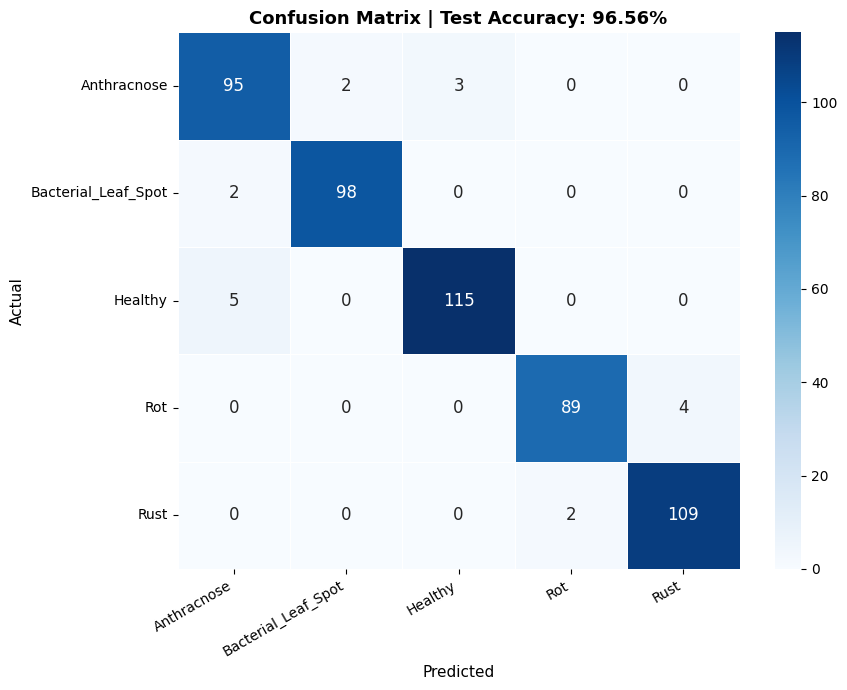


 Final model saved: /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/saved/efficientnetb4_v3.keras


In [ ]:
#load checkpoint and evaluate
# sklearn reinstall + restart check
import sklearn
print(f"sklearn version: {sklearn.__version__}")

from google.colab import drive
import os, tensorflow as tf, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

drive.mount('/content/drive')

BASE_PATH      = "/content/drive/MyDrive/bio-heritage-ai/plant_disease"
PROCESSED_PATH = f"{BASE_PATH}/datasets/processed"
CHECKPOINT     = f"{BASE_PATH}/models/checkpoints/best_model_v3.keras"
MODEL_SAVE     = f"{BASE_PATH}/models/saved/efficientnetb4_v3.keras"
IMG_SIZE, BATCH_SIZE = 224, 16

# Generators
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = val_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    f"{PROCESSED_PATH}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Load best model
model = tf.keras.models.load_model(CHECKPOINT)
print(f" Model loaded!")
print(f"   Classes: {test_gen.class_indices}")

# Val Accuracy
print("\n Evaluating on Val set...")
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"   Val Accuracy : {val_acc*100:.2f}%")

# Test Evaluation
print("\n Evaluating on Test set...")
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes
class_names = list(test_gen.class_indices.keys())

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='macro')

print(f"\n{'='*45}")
print(f"  FINAL RESULTS")
print(f"{'='*45}")
print(f"  Val Accuracy   : {val_acc*100:.2f}%")
print(f"  Test Accuracy  : {acc*100:.2f}%")
print(f"  Macro F1 Score : {f1*100:.2f}%")
print(f"{'='*45}\n")
print(classification_report(y_true, y_pred, target_names=class_names))

#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues', linewidths=0.5,
            annot_kws={"size": 12})
plt.title(f'Confusion Matrix | Test Accuracy: {acc*100:.2f}%',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
os.makedirs(f"{BASE_PATH}/results/plots", exist_ok=True)
plt.savefig(f"{BASE_PATH}/results/plots/confusion_matrix_v3.png", dpi=150)
plt.show()

#  Save final model
model.save(MODEL_SAVE)
print(f"\n Final model saved: {MODEL_SAVE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 4183 images belonging to 5 classes.
Found 522 images belonging to 5 classes.
Found 524 images belonging to 5 classes.
 Model loaded!

 Evaluating Train...
262/262 ━━━━━━━━━━━━━━━━━━━━ 1560s 6s/step - accuracy: 0.9823 - loss: 0.0607

 Evaluating Val...
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9789 - loss: 0.0846

 Evaluating Test...
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9656 - loss: 0.0787
  ACCURACY SUMMARY
  Train Accuracy : 98.23%
  Val Accuracy   : 97.89%
  Test Accuracy  : 96.56%
  Train-Val Gap  : 0.34%
   Not overfit — Excellent!

  Macro F1 Score : 96.55%

                     precision    recall  f1-score   support

        Anthracnose       0.93      0.95      0.94       100
Bacterial_Leaf_Spot       0.98      0.98      0.98       100
            Healthy       0.97      0.96      0.97       120
                Rot

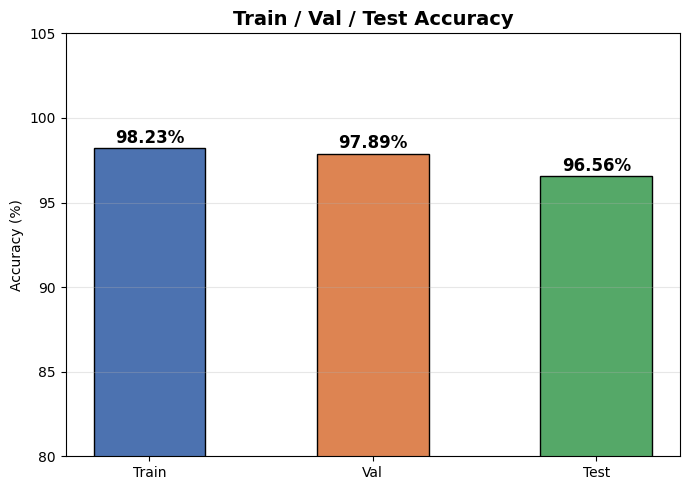

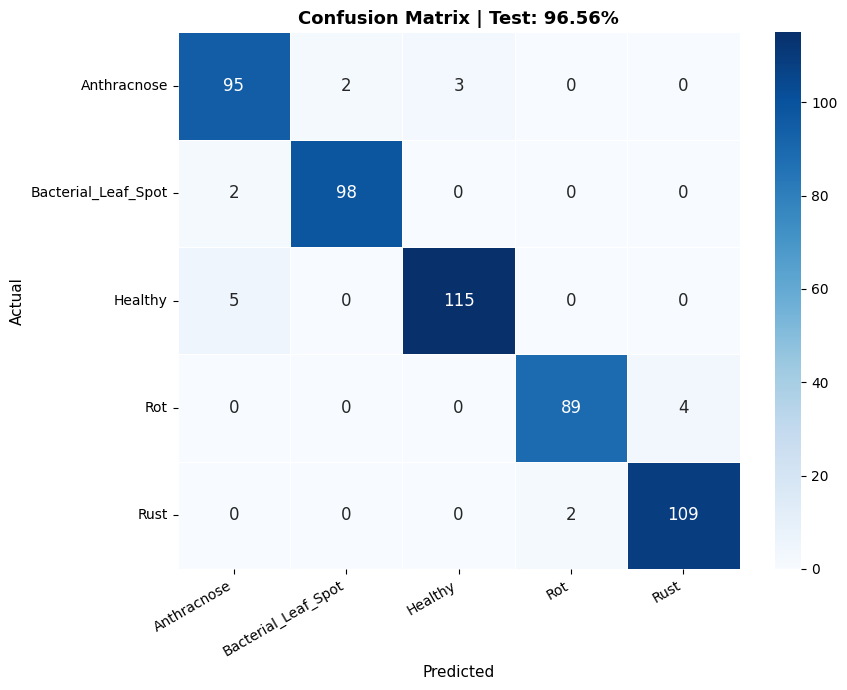

 Final model saved: /content/drive/MyDrive/bio-heritage-ai/plant_disease/models/saved/efficientnetb4_v3.keras


In [ ]:
from google.colab import drive
import os, tensorflow as tf, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

drive.mount('/content/drive')

BASE_PATH      = "/content/drive/MyDrive/bio-heritage-ai/plant_disease"
PROCESSED_PATH = f"{BASE_PATH}/datasets/processed"
CHECKPOINT     = f"{BASE_PATH}/models/checkpoints/best_model_v3.keras"
MODEL_SAVE     = f"{BASE_PATH}/models/saved/efficientnetb4_v3.keras"
IMG_SIZE, BATCH_SIZE = 224, 16

#  Generators
no_aug = ImageDataGenerator(preprocessing_function=preprocess_input)

train_eval_gen = no_aug.flow_from_directory(
    f"{PROCESSED_PATH}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
val_gen = no_aug.flow_from_directory(
    f"{PROCESSED_PATH}/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = no_aug.flow_from_directory(
    f"{PROCESSED_PATH}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Load model
model = tf.keras.models.load_model(CHECKPOINT)
print(f" Model loaded!")

# Evaluate all 3
print("\n Evaluating Train...")
_, train_acc = model.evaluate(train_eval_gen, verbose=1)

print("\n Evaluating Val...")
_, val_acc = model.evaluate(val_gen, verbose=1)

print("\n Evaluating Test...")
_, test_acc = model.evaluate(test_gen, verbose=1)

gap = abs(train_acc - val_acc)


print(f"  ACCURACY SUMMARY")

print(f"  Train Accuracy : {train_acc*100:.2f}%")
print(f"  Val Accuracy   : {val_acc*100:.2f}%")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Train-Val Gap  : {gap*100:.2f}%")

if gap < 0.03:
    print("   Not overfit — Excellent!")
elif gap < 0.07:
    print("   Acceptable — Mild gap")
else:
    print("    Possible overfit")

#  Classification Report
y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())
f1 = f1_score(y_true, y_pred, average='macro')
print(f"\n  Macro F1 Score : {f1*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=class_names))

#  Bar Chart
plt.figure(figsize=(7, 5))
bars = plt.bar(['Train', 'Val', 'Test'],
               [train_acc*100, val_acc*100, test_acc*100],
               color=['#4C72B0','#DD8452','#55A868'],
               width=0.5, edgecolor='black')
for bar, val in zip(bars, [train_acc*100, val_acc*100, test_acc*100]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.ylim([80, 105])
plt.title('Train / Val / Test Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
os.makedirs(f"{BASE_PATH}/results/plots", exist_ok=True)
plt.savefig(f"{BASE_PATH}/results/plots/accuracy_bar_v3.png", dpi=150)
plt.show()

#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues', linewidths=0.5,
            annot_kws={"size": 12})
plt.title(f'Confusion Matrix | Test: {test_acc*100:.2f}%',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/results/plots/confusion_matrix_v3.png", dpi=150)
plt.show()

#  Save
model.save(MODEL_SAVE)
print(f" Final model saved: {MODEL_SAVE}")

Model loaded!

Upload a leaf image...


Saving health-benefits-of-aloe-vera-alt-1440x810.webp to health-benefits-of-aloe-vera-alt-1440x810.webp

Predicting: health-benefits-of-aloe-vera-alt-1440x810.webp


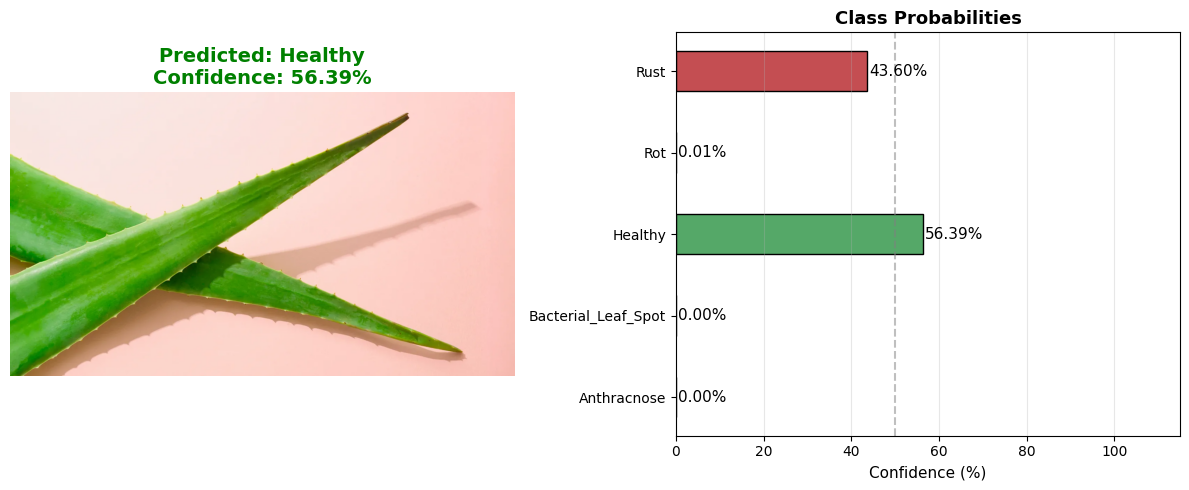

  RESULT     : Healthy
  Confidence : 56.39%
  Plant is Healthy!

  All probabilities (high to low):
  Healthy                  : 56.39%  ||||||||||||||||
  Rust                     : 43.60%  |||||||||||||
  Rot                      : 0.01%  
  Anthracnose              : 0.00%  
  Bacterial_Leaf_Spot      : 0.00%  


In [5]:
from google.colab import files
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

BASE_PATH   = "/content/drive/MyDrive/bio-heritage-ai/plant_disease"
CHECKPOINT  = f"{BASE_PATH}/models/checkpoints/best_model_v3.keras"
CLASS_NAMES = ['Anthracnose', 'Bacterial_Leaf_Spot', 'Healthy', 'Rot', 'Rust']

#  Load model
model = tf.keras.models.load_model(CHECKPOINT)
print("Model loaded!")

#  Fix: retracing warning
@tf.function(reduce_retracing=True)
def run_inference(x):
    return model(x, training=False)

#  Predict function
def predict_image(img_path):
    # Image load + preprocess
    img         = Image.open(img_path).convert('RGB')
    img_resized = img.resize((224, 224))
    img_array   = np.array(img_resized, dtype=np.float32)
    img_array   = preprocess_input(img_array)
    img_array   = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = run_inference(tf.constant(img_array)).numpy()[0]
    pred_idx    = np.argmax(predictions)
    pred_class  = CLASS_NAMES[pred_idx]
    confidence  = predictions[pred_idx] * 100

    #  Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left — original image
    axes[0].imshow(img)
    axes[0].axis('off')
    color = 'green' if pred_class == 'Healthy' else 'red'
    axes[0].set_title(
        f"Predicted: {pred_class}\nConfidence: {confidence:.2f}%",
        fontsize=14, fontweight='bold', color=color
    )

    # Right — probability bar chart
    bar_colors = ['#55A868' if c == 'Healthy' else '#C44E52' for c in CLASS_NAMES]
    bars = axes[1].barh(CLASS_NAMES, predictions * 100,
                        color=bar_colors, edgecolor='black', height=0.5)
    for bar, val in zip(bars, predictions * 100):
        axes[1].text(bar.get_width() + 0.5,
                     bar.get_y() + bar.get_height() / 2,
                     f'{val:.2f}%', va='center', fontsize=11)
    axes[1].set_xlim([0, 115])
    axes[1].set_xlabel('Confidence (%)', fontsize=11)
    axes[1].set_title('Class Probabilities', fontsize=13, fontweight='bold')
    axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.5)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    #  Text output

    print(f"  RESULT     : {pred_class}")
    print(f"  Confidence : {confidence:.2f}%")

    if pred_class == 'Healthy':
        print("  Plant is Healthy!")
    else:
        print(f"  Disease Detected: {pred_class}")

    print("\n  All probabilities (high to low):")
    for cls, prob in sorted(zip(CLASS_NAMES, predictions),
                            key=lambda x: x[1], reverse=True):
        bar = '|' * int(prob * 30)
        print(f"  {cls:<25}: {prob*100:.2f}%  {bar}")

#  Upload & predict
print("\nUpload a leaf image...")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nPredicting: {filename}")
    predict_image(filename)